<a href="https://colab.research.google.com/github/raffinJ/Estudo-de-Cusltura-de-Seguran-a-do-Paciente-e-Mortalidade-Hospitalar/blob/main/dados_emilie_tea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalando & Importando pacotes

In [ ]:
!pip install dbfread

In [ ]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.0 MB/s eta 0:00:00


In [ ]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.8 MB/s eta 0:00:00


In [ ]:
!pip install polars pyarrow duckdb

In [ ]:
from docx import Document
from docx.shared import Inches

In [ ]:
import polars as pl

In [ ]:
from google.colab import files

In [ ]:
pl.Config.set_fmt_float("full")

polars.config.Config

# Conectando

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/custo_TEA/emilie/SIA_TEA_definitivo.csv"

df = pl.scan_csv(
    path,
    schema_overrides={
        "PA_CIDPRI": pl.String,
        "PA_CIDSEC": pl.String,
        "PA_PROC_ID": pl.String,
        "PA_CBOCOD": pl.String,
        "PA_CIDCAS": pl.String  # Added to handle 'NA' values
    },
    infer_schema_length=10000
)

df

# vars do df

In [ ]:
df.collect_schema()

Schema([('PA_CODUNI', Int64),
        ('PA_GESTAO', Int64),
        ('PA_UFMUN', Int64),
        ('PA_PROC_ID', String),
        ('PA_TPFIN', Int64),
        ('PA_CBOCOD', String),
        ('PA_OBITO', Int64),
        ('PA_CIDPRI', String),
        ('PA_CIDSEC', String),
        ('PA_CIDCAS', String),
        ('PA_CATEND', Int64),
        ('PA_IDADE', Int64),
        ('PA_SEXO', String),
        ('PA_RACACOR', Int64),
        ('PA_MUNPCN', Int64),
        ('PA_QTDPRO', Int64),
        ('PA_QTDAPR', Int64),
        ('PA_VALPRO', Float64),
        ('PA_VALAPR', Float64),
        ('PA_UFDIF', Int64),
        ('PA_MNDIF', Int64),
        ('ano', Int64),
        ('cod_municipio', Int64),
        ('cod_uf', Int64),
        ('munResUf', String),
        ('Regiao', String),
        ('FaixaEtaria', String)])

In [ ]:
df.head().collect()

PA_CODUNI,PA_GESTAO,PA_UFMUN,PA_PROC_ID,PA_TPFIN,PA_CBOCOD,PA_OBITO,PA_CIDPRI,PA_CIDSEC,PA_CIDCAS,PA_CATEND,PA_IDADE,PA_SEXO,PA_RACACOR,PA_MUNPCN,PA_QTDPRO,PA_QTDAPR,PA_VALPRO,PA_VALAPR,PA_UFDIF,PA_MNDIF,ano,cod_municipio,cod_uf,munResUf,Regiao,FaixaEtaria
i64,i64,i64,str,i64,str,i64,str,str,str,i64,i64,str,i64,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,str,str,str
5786592,120000,120040,"""803010087""",6,"""225125""",0,"""F840""","""0000""","""0""",1,7,"""M""",99,120040,6,6,1089,1089,0,0,2013,120040,12,"""Acre""","""Norte""","""0-12 anos"""
5786592,120000,120040,"""803010087""",6,"""225125""",0,"""F840""","""0000""","""0""",1,7,"""M""",99,120040,6,6,1089,1089,0,0,2013,120040,12,"""Acre""","""Norte""","""0-12 anos"""
5786592,120000,120040,"""803010087""",6,"""225125""",0,"""F840""","""0000""","""0""",1,3,"""F""",99,120040,6,6,1089,1089,0,0,2013,120040,12,"""Acre""","""Norte""","""0-12 anos"""
5786592,120000,120040,"""803010125""",6,"""225125""",0,"""F840""","""0000""","""0""",1,5,"""M""",99,120060,8,8,39.6,39.6,0,1,2013,120040,12,"""Acre""","""Norte""","""0-12 anos"""
5786592,120000,120040,"""803010125""",6,"""225125""",0,"""F840""","""0000""","""0""",1,9,"""F""",99,120020,12,12,59.4,59.4,0,1,2013,120040,12,"""Acre""","""Norte""","""0-12 anos"""


# Excluindo registros com idade >60 anos

In [ ]:
df = df.filter(pl.col('PA_IDADE') <= 59)

# Corrigindo custo IPCA

In [ ]:
fatores = {
    2013: 2.0684203,
    2014: 1.9485257,
    2015: 1.8020442,
    2016: 1.6474036,
    2017: 1.5753919,
    2018: 1.5342636,
    2019: 1.4671367,
    2020: 1.4202272,
    2021: 1.3385827,
    2022: 1.2026872,
    2023: 1.1492396,
    2024: 1.1058292,
    2025: 1.048406,
    2026: 1.0
}

In [ ]:
df = df.with_columns(
    (
        pl.col("PA_VALAPR") *
        pl.col("ano").replace_strict(fatores)
    ).alias("custo_corrigido")
)

resultado = (
    df
    .select([
        "ano",
        "PA_VALAPR",
        "custo_corrigido"
    ])
    .head(10)
    .collect()
)

resultado

ano,PA_VALAPR,custo_corrigido
i64,f64,f64
2013,1089,2252.5097067
2013,1089,2252.5097067
2013,1089,2252.5097067
2013,39.6,81.90944388000001
2013,59.4,122.86416582
2013,1089,2252.5097067
2013,1089,2252.5097067
2013,1089,2252.5097067
2013,1089,2252.5097067


# Convertendo para Dolar Internacional

In [ ]:
df = df.with_columns(
    (pl.col("custo_corrigido") / 2.49).alias("custo_dolar_int")
)

# Excluindo custos zerados

In [ ]:
df_custo_zero = df.filter(pl.col("custo_corrigido") == 0)

# Collect the LazyFrame to a Polars DataFrame and then convert to Pandas
df_custo_zero_pandas = df_custo_zero.collect().to_pandas()

# Define the filename for the CSV file
file_name = "linhas_custo_zero.csv"

# Save the Pandas DataFrame to a CSV file
df_custo_zero_pandas.to_csv(file_name, index=False)

# Download the file
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df = df.filter(pl.col('PA_VALAPR') > 0)

# Funções

Função **resumo_geral** deve ser usada para a análise sem agrupamentos (por ano, por exemplo) = análises totais considerando tudo

In [ ]:
def resumo_geral(dataframe, nome_cenario):

    return (
        dataframe

        .select([
            pl.len().alias("n_apacs"),

            pl.sum("PA_QTDAPR")
            .alias("qtd_aprovada"),

            pl.sum("custo_corrigido")
            .round(2)
            .alias("custo_total"),

            pl.median("custo_corrigido")
            .round(2)
            .alias("custo_mediana"),

            pl.sum("custo_dolar_int")
            .round(2)
            .alias("custo_dolar_int"),

            pl.median("custo_dolar_int")
            .round(2)
            .alias("custo_int_mediana")
        ])

        .with_columns(
            pl.lit(nome_cenario).alias("cenario")
        )
    )

Função **resumo_agrupado** deve ser usada para a análise com agrupamentos (por ano, por UF...) = análises agrupadas

In [ ]:
def resumo_agrupado(dataframe, agrupamentos, nome_cenario):

    return (
        dataframe

        .group_by(agrupamentos)

        .agg([
            pl.len().alias("n_apacs"),

            pl.sum("PA_QTDAPR")
            .alias("qtd_aprovada"),

            pl.sum("custo_corrigido")
            .round(2)
            .alias("custo_total"),

            pl.median("custo_corrigido")
            .round(2)
            .alias("custo_mediana"),

            pl.sum("custo_dolar_int")
            .round(2)
            .alias("custo_dolar_int"),

            pl.median("custo_dolar_int")
            .round(2)
            .alias("custo_int_mediana")
        ])

        .with_columns(
            pl.lit(nome_cenario).alias("cenario")
        )

        .sort(agrupamentos)
    )

# Análise geral

In [ ]:
base_total = resumo_geral(
    df,
    "Base total"
)

In [ ]:
cid_principal = resumo_geral(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    "CID primário F840/F845"
)

In [ ]:
cid_secundario = resumo_geral(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    "CID secundário F840/F845"
)

In [ ]:
resultado_final = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

resultado_final.sort([
    "cenario"
]).collect()

n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
u32,i64,f64,f64,f64,f64,str
19819203,65929896,707226357.22,19.54,284026649.49,7.85,"""Base total"""
19817852,65847637,706969924.11,19.54,283923664.3,7.85,"""CID primário F840/F845"""
1394,82999,261202.56,11.81,104900.63,4.74,"""CID secundário F840/F845"""


In [ ]:
tabela = (
    resultado_final
    .sort(["cenario"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Produção ambulatorial relacionada ao TEA',
    level=1
)

# cria tabela no Word
table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

# cabeçalhos
hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

# linhas
for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# salva
doc.save("tabela_autismo.docx")

In [ ]:
files.download("tabela_autismo.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Análise Individual por CID Primário (F840 e F845)

In [ ]:
cid_f840 = resumo_geral(
    df.filter(
        pl.col("PA_CIDPRI") == "F840"
    ),
    "CID Primário F840"
)

cid_f845 = resumo_geral(
    df.filter(
        pl.col("PA_CIDPRI") == "F845"
    ),
    "CID Primário F845"
)

resultado_cid_individual = pl.concat([
    cid_f840,
    cid_f845
])

resultado_cid_individual.sort([
    "cenario"
]).collect()

n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
u32,i64,f64,f64,f64,f64,str
19668245,64930475,700377753.85,19.54,281276206.37,7.85,"""CID Primário F840"""
149607,917162,6592170.26,23.65,2647457.94,9.5,"""CID Primário F845"""


In [ ]:
csv_file_name = "analise_cid_individual.csv"
resultado_cid_individual.collect().write_csv(csv_file_name)

from google.colab import files
files.download(csv_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise temporal

In [ ]:
base_total = resumo_agrupado(
    df,
    ["ano"],
    "Base total"
)

cid_principal = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["ano"],
    "CID primário F840/F845"
)

cid_secundario = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["ano"],
    "CID secundário F840/F845"
)

In [ ]:
resultado_final = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

resultado_final.sort([
    "cenario",
    "ano"
]).collect()

ano,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
i64,u32,i64,f64,f64,f64,f64,str
2013,131364,578084,17431585.97,31.56,7000636.94,12.68,"""Base total"""
2014,174300,673209,19262950.83,29.73,7736124.83,11.94,"""Base total"""
2015,242004,776396,20536099.88,27.5,8247429.67,11.04,"""Base total"""
2016,310224,1061244,22615000.19,25.14,9082329.4,10.1,"""Base total"""
2017,393992,1746108,26231756.98,24.04,10534842.16,9.65,"""Base total"""
…,…,…,…,…,…,…,…
2021,152,11031,14208.61,13.25,5706.27,5.32,"""CID secundário F840/F845"""
2022,155,8567,42406.37,14.43,17030.67,5.8,"""CID secundário F840/F845"""
2023,112,7476,9362.21,11.38,3759.92,4.57,"""CID secundário F840/F845"""


In [ ]:
tabela = (
    resultado_final
    .sort(["cenario", "ano"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Resumo geral sem agregação por ano',
    level=1
)

table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

doc.save("tabela_autismo_ano.docx")

In [ ]:
files.download("tabela_autismo_ano.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

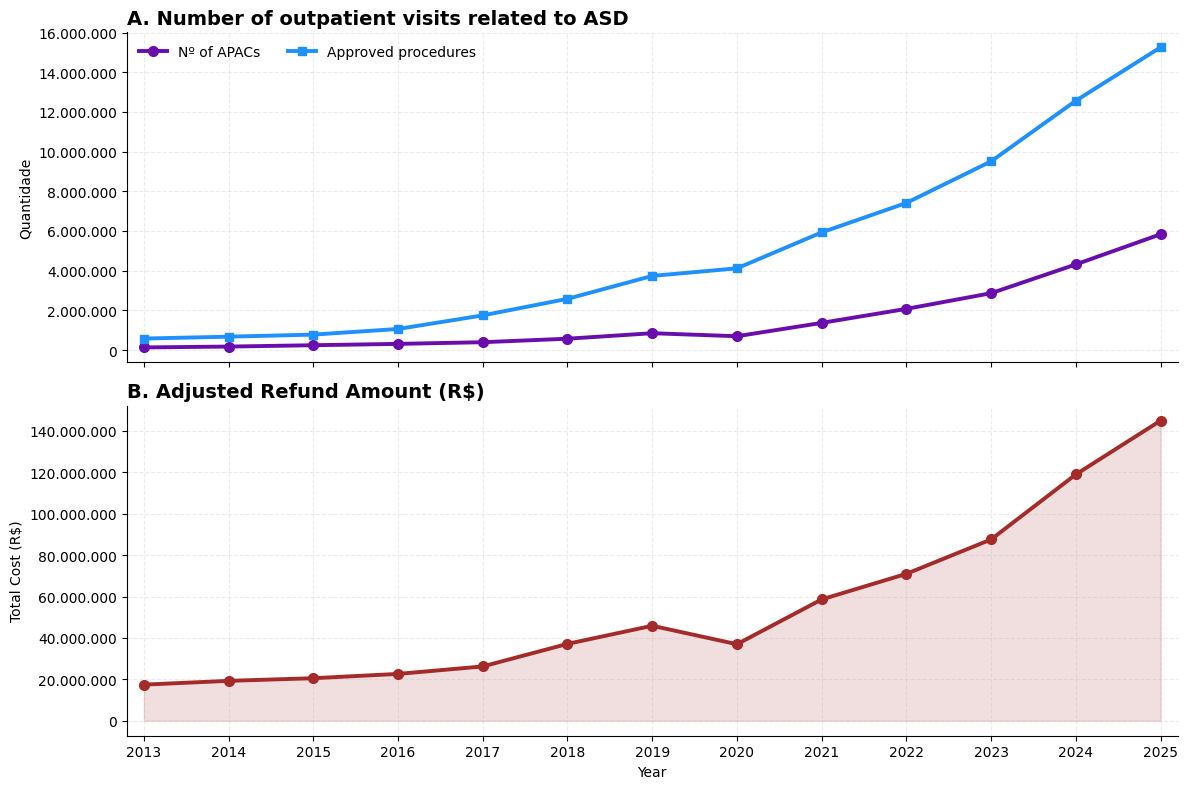

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# ==================================
# DADOS
# ==================================

df_plot_data = resultado_final.collect().to_pandas()

for col in ['n_apacs', 'qtd_aprovada', 'custo_total']:
    df_plot_data[col] = pd.to_numeric(df_plot_data[col], errors='coerce')

# Filtrar apenas Base Total
df_plot_data = (
    df_plot_data
    .query("cenario == 'Base total'")
    .sort_values('ano')
)

anos = sorted(df_plot_data['ano'].unique())

# ==================================
# CORES
# ==================================

COR_APAC = "#6A0DAD"      # Roxo
COR_PROC = "#1E90FF"      # Dodger Blue
COR_CUSTO = "#A52A2A"     # Brown

# ==================================
# FORMATADOR
# ==================================

def formato_br(x, pos):
    return f'{int(x):,}'.replace(',', '.')

formatter = FuncFormatter(formato_br)

# ==================================
# FIGURA
# ==================================

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 1]}
)

# =====================================================
# PAINEL A - VOLUME ASSISTENCIAL
# =====================================================

ax1.plot(
    df_plot_data['ano'],
    df_plot_data['n_apacs'],
    color=COR_APAC,
    marker='o',
    linewidth=2.8,
    markersize=7,
    label='Nº of APACs'
)

ax1.plot(
    df_plot_data['ano'],
    df_plot_data['qtd_aprovada'],
    color=COR_PROC,
    marker='s',
    linewidth=2.8,
    markersize=6,
    label='Approved procedures'
)

ax1.set_title(
    'A. Number of outpatient visits related to ASD',
    fontsize=14,
    fontweight='bold',
    loc='left'
)

ax1.set_ylabel('Quantidade')

ax1.yaxis.set_major_formatter(formatter)

ax1.grid(
    True,
    linestyle='--',
    alpha=0.25
)

ax1.legend(
    frameon=False,
    ncol=2,
    loc='upper left'
)

# =====================================================
# PAINEL B - CUSTOS
# =====================================================

ax2.plot(
    df_plot_data['ano'],
    df_plot_data['custo_total'],
    color=COR_CUSTO,
    marker='o',
    linewidth=2.8,
    markersize=7
)

ax2.fill_between(
    df_plot_data['ano'],
    df_plot_data['custo_total'],
    alpha=0.15,
    color=COR_CUSTO
)

ax2.set_title(
    'B. Adjusted Refund Amount (R$)',
    fontsize=14,
    fontweight='bold',
    loc='left'
)

ax2.set_ylabel('Total Cost (R$)')
ax2.set_xlabel('Year')

ax2.yaxis.set_major_formatter(formatter)

ax2.grid(
    True,
    linestyle='--',
    alpha=0.25
)

# =====================================================
# AJUSTES GERAIS
# =====================================================

for ax in [ax1, ax2]:

    ax.set_xticks(anos)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_xlim(
        min(anos)-0.2,
        max(anos)+0.2
    )

plt.tight_layout()

# Salvar em alta resolução para artigo
plt.savefig("Figura_1_TEA_APACs_Custos.png",
             dpi=600,
             bbox_inches="tight")

plt.show()

# Análise temporal da média de idade

In [ ]:
def resumo_idade_agrupado(dataframe, agrupamentos, nome_cenario):
    # Ensure 'idade' column exists before aggregation
    dataframe_with_idade = dataframe.with_columns(
        pl.col("PA_IDADE").cast(pl.Int64, strict=False).alias("idade")
    )
    return (
        dataframe_with_idade
        .group_by(agrupamentos)
        .agg([
            pl.mean("idade").round(2).alias("idade_media"),
            pl.std("idade").round(2).alias("idade_dp"),
            pl.min("idade").alias("idade_minima"),
            pl.max("idade").alias("idade_maxima"),
            pl.median("idade").round(2).alias("idade_mediana")
        ])
        .with_columns(
            pl.lit(nome_cenario).alias("cenario")
        )
        .sort(agrupamentos)
    )

idade_base_total_temporal = resumo_idade_agrupado(
    df,
    ["ano"],
    "Base total"
)

idade_cid_principal_temporal = resumo_idade_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["ano"],
    "CID primário F840/F845"
)

idade_cid_secundario_temporal = resumo_idade_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["ano"],
    "CID secundário F840/F845"
)

resultado_idade_temporal = pl.concat([
    idade_base_total_temporal,
    idade_cid_principal_temporal,
    idade_cid_secundario_temporal
])

display(resultado_idade_temporal.sort([
    "cenario",
    "ano"
]).collect())

ano,idade_media,idade_dp,idade_minima,idade_maxima,idade_mediana,cenario
i64,f64,f64,i64,i64,f64,str
2013,11.74,8.22,0,59,9,"""Base total"""
2014,11.23,7.89,0,59,9,"""Base total"""
2015,10.5,7.34,0,59,8,"""Base total"""
2016,9.96,7.08,0,59,8,"""Base total"""
2017,9.66,7.12,0,59,8,"""Base total"""
…,…,…,…,…,…,…
2021,20.1,13.99,1,58,14,"""CID secundário F840/F845"""
2022,15.5,9.66,0,41,14,"""CID secundário F840/F845"""
2023,16.46,9.2,4,42,15,"""CID secundário F840/F845"""


In [ ]:
csv_file_name = "analise_idade_temporal.xlsx"
resultado_idade_temporal.collect().to_pandas().to_excel(csv_file_name, index=False, engine='xlsxwriter')

from google.colab import files
files.download(csv_file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise da idade

Primeiro, transforma var IDADE em numeric (int64)

In [ ]:
df = df.with_columns(
    pl.col("PA_IDADE")
    .cast(pl.Int64, strict=False)
    .alias("idade")
)

Segundo, cria categorias de idade

In [ ]:
df = df.with_columns(
    pl.when(pl.col("idade") <= 4)
    .then(pl.lit("0-4"))

    .when(pl.col("idade") <= 9)
    .then(pl.lit("5-9"))

    .when(pl.col("idade") <= 14)
    .then(pl.lit("10-14"))

    .when(pl.col("idade") <= 19)
    .then(pl.lit("15-19"))

    .otherwise(pl.lit("20+"))

    .alias("faixa_etaria")
)

Análise de média da idade geral

In [ ]:
def resumo_idade(dataframe, nome_cenario):
    return (
        dataframe
        .select([
            pl.mean("idade").round(2).alias("idade_media"),
            pl.std("idade").round(2).alias("idade_dp"),
            pl.min("idade").alias("idade_minima"),
            pl.max("idade").alias("idade_maxima"),
            pl.median("idade").round(2).alias("idade_mediana")
        ])
        .with_columns(pl.lit(nome_cenario).alias("cenario"))
        .collect()
    )

idade_base_total = resumo_idade(
    df,
    "Base total"
)

idade_cid_principal = resumo_idade(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    "CID primário F840/F845"
)

idade_cid_secundario = resumo_idade(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    "CID secundário F840/F845"
)

idade_resumo_completo = pl.concat([
    idade_base_total,
    idade_cid_principal,
    idade_cid_secundario
])

display(idade_resumo_completo.sort(["cenario"]))

idade_media,idade_dp,idade_minima,idade_maxima,idade_mediana,cenario
f64,f64,i64,i64,f64,str
8.17,5.86,0,59,7,"""Base total"""
8.17,5.86,0,59,7,"""CID primário F840/F845"""
15.72,11.44,0,58,12,"""CID secundário F840/F845"""


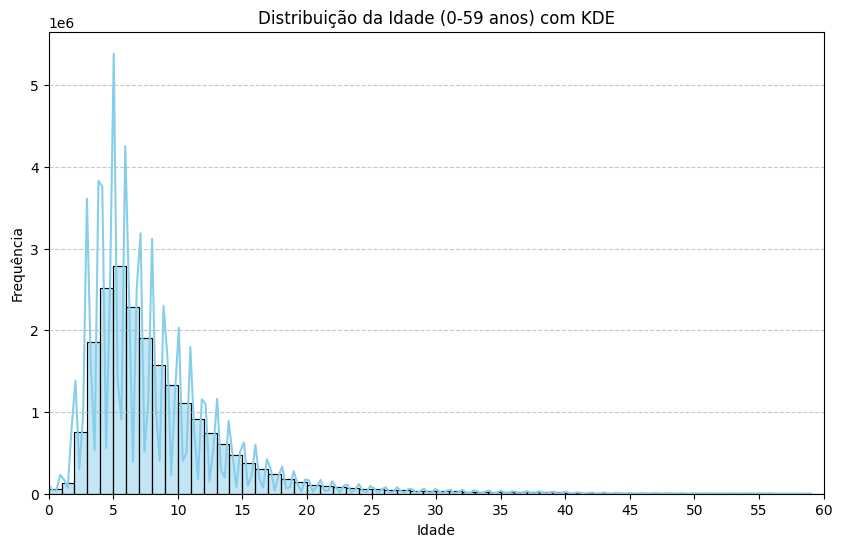

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Collect the 'PA_IDADE' column from the Polars LazyFrame and convert to Pandas Series
# We filter out nulls that represent ages > 59
age_data = df.select('PA_IDADE').collect().to_pandas()['PA_IDADE'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(age_data, kde=True, bins=range(0, 61, 1), color='skyblue')

plt.title('Distribuição da Idade (0-59 anos) com KDE')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 60) # Ensure the x-axis matches the age range
plt.xticks(np.arange(0, 61, 5)) # Set x-ticks for better readability

plt.show()

In [ ]:
idade_f840 = (
    df.filter(pl.col("PA_CIDPRI") == "F840")
    .select([
        pl.mean("idade").round(2).alias("idade_media"),
        pl.std("idade").round(2).alias("idade_dp")
    ])
    .with_columns(pl.lit("CID Primário F840").alias("cenario"))
    .collect()
)

idade_f845 = (
    df.filter(pl.col("PA_CIDPRI") == "F845")
    .select([
        pl.mean("idade").round(2).alias("idade_media"),
        pl.std("idade").round(2).alias("idade_dp")
    ])
    .with_columns(pl.lit("CID Primário F845").alias("cenario"))
    .collect()
)

idade_cid_individual = pl.concat([
    idade_f840,
    idade_f845
])

display(idade_cid_individual)

idade_media,idade_dp,cenario
f64,f64,str
8.16,5.85,"""CID Primário F840"""
13.32,8.97,"""CID Primário F845"""


Análise de freq e custo por grupo de idade

In [ ]:
faixa_total = resumo_agrupado(
    df,
    ["faixa_etaria"],
    "Base total"
)

faixa_cidpri = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["faixa_etaria"],
    "CID primário"
)

faixa_cidsec = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["faixa_etaria"],
    "CID secundário"
)

In [ ]:
resultado_faixa = pl.concat([
    faixa_total,
    faixa_cidpri,
    faixa_cidsec
])

resultado_faixa.collect()

faixa_etaria,n_apacs,qtd_aprovada,custo_total,cenario
str,u32,i64,f64,str
"""0-4""",5316979,7885768,1.4443e8,"""Base total"""
"""10-14""",3860189,18547015,1.4352e8,"""Base total"""
"""15-19""",1253738,9222625,5.3988e7,"""Base total"""
"""20+""",940648,7609147,4.8256e7,"""Base total"""
"""5-9""",9891886,23159072,3.1785e8,"""Base total"""
…,…,…,…,…
"""0-4""",148,1112,99336.83,"""CID secundário"""
"""10-14""",653,32878,41416.5,"""CID secundário"""
"""15-19""",521,33653,8234.13,"""CID secundário"""


# Análise por Região

In [ ]:
base_total = resumo_agrupado(
    df,
    ["Regiao"],
    "Base total"
)

cid_principal = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["Regiao"],
    "CID primário F840/F845"
)

cid_secundario = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["Regiao"],
    "CID secundário F840/F845"
)

In [ ]:
resultado_regiao = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

In [ ]:
tabela = (
    resultado_regiao
    .sort(["cenario", "Regiao"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Produção ambulatorial relacionada ao TEA',
    level=1
)

# cria tabela no Word
table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

# cabeçalhos
hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

# linhas
for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# salva
doc.save("regiao.docx")

files.download("regiao.docx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise por UF

In [ ]:
base_total = resumo_agrupado(
    df,
    ["munResUf"],
    "Base total"
)

cid_principal = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["munResUf"],
    "CID primário F840/F845"
)

cid_secundario = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["munResUf"],
    "CID secundário F840/F845"
)

In [ ]:
resultado_ufs = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

In [ ]:
tabela = (
    resultado_ufs
    .sort(["cenario", "munResUf"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Produção ambulatorial relacionada ao TEA',
    level=1
)

# cria tabela no Word
table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

# cabeçalhos
hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

# linhas
for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# salva
doc.save("ufs.docx")



In [ ]:
files.download("ufs.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

UF vs ANO

In [ ]:
base_total = resumo_agrupado(
    df,
    ["ano", "UF_PART"],
    "Base total"
)

cid_principal = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["ano", "UF_PART"],
    "CID primário F840/F845"
)

cid_secundario = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["ano", "UF_PART"],
    "CID secundário F840/F845"
)

In [ ]:
resultado_ufs = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

In [ ]:
tabela = (
    resultado_ufs
    .sort(["cenario", "UF_PART", "ano"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

ColumnNotFoundError: unable to find column "UF_PART"; valid columns: ["PA_CODUNI", "PA_GESTAO", "PA_UFMUN", "PA_PROC_ID", "PA_TPFIN", "PA_CBOCOD", "PA_OBITO", "PA_CIDPRI", "PA_CIDSEC", "PA_CIDCAS", "PA_CATEND", "PA_IDADE", "PA_SEXO", "PA_RACACOR", "PA_MUNPCN", "PA_QTDPRO", "PA_QTDAPR", "PA_VALPRO", "PA_VALAPR", "PA_UFDIF", "PA_MNDIF", "ano", "cod_municipio", "cod_uf", "munResUf", "Regiao", "FaixaEtaria", "custo_corrigido"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'sink' <---
 WITH_COLUMNS:
 [[(col("PA_VALAPR")) * (col("ano").replace_strict([[2013, 2014, … 2026], [2.0684203, 1.9485257, … 1]]))].alias("custo_corrigido")] 
  FILTER [(col("PA_IDADE")) <= (59)]
  FROM
    Csv SCAN [/content/drive/MyDrive/custo_TEA/emilie/SIA_TEA_definitivo.csv]
    PROJECT */27 COLUMNS
    ESTIMATED ROWS: 21672113

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Produção ambulatorial relacionada ao TEA',
    level=1
)

# cria tabela no Word
table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

# cabeçalhos
hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

# linhas
for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# salva
doc.save("ufs_ANO.docx")



# Análise por Sexo

In [ ]:
base_total = resumo_agrupado(
    df,
    ["PA_SEXO"],
    "Base total"
)

base_total.collect()

PA_SEXO,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
str,u32,i64,f64,f64,f64,f64,str
"""F""",4530828,13886603,160096868.33,19.54,64295931.06,7.85,"""Base total"""
"""M""",15288375,52043293,547129488.89,20.31,219730718.43,8.16,"""Base total"""


## Análise por Sexo

In [ ]:
base_total_sexo = resumo_agrupado(
    df,
    ["PA_SEXO"],
    "Base total"
)

cid_principal_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["PA_SEXO"],
    "CID primário F840/F845"
)

cid_f840_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI") == "F840"
    ),
    ["PA_SEXO"],
    "CID primário F840"
)

cid_f845_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI") == "F845"
    ),
    ["PA_SEXO"],
    "CID primário F845"
)

cid_secundario_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["PA_SEXO"],
    "CID secundário F840/F845"
)

resultado_sexo_completo = pl.concat([
    base_total_sexo,
    cid_principal_sexo,
    cid_f840_sexo,
    cid_f845_sexo,
    cid_secundario_sexo
])

display(resultado_sexo_completo.sort(["cenario", "PA_SEXO"]).collect())

PA_SEXO,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
str,u32,i64,f64,f64,f64,f64,str
"""F""",4530828,13886603,160096868.33,19.54,64295931.06,7.85,"""Base total"""
"""M""",15288375,52043293,547129488.89,20.31,219730718.43,8.16,"""Base total"""
"""F""",4505126,13699980,158929275.92,19.54,63827018.44,7.85,"""CID primário F840"""
"""M""",15163119,51230495,541448477.93,19.81,217449187.92,7.96,"""CID primário F840"""
"""F""",4530285,13850922,160026836.84,19.54,64267805.96,7.85,"""CID primário F840/F845"""
"""M""",15287567,51996715,546943087.28,20.31,219655858.34,8.16,"""CID primário F840/F845"""
"""F""",25159,150942,1097560.92,23.65,440787.52,9.5,"""CID primário F845"""
"""M""",124448,766220,5494609.35,23.65,2206670.42,9.5,"""CID primário F845"""
"""F""",543,35681,70031.49,9.44,28125.1,3.79,"""CID secundário F840/F845"""


# Análise por grupo de raça/cor

In [ ]:
base_total_sexo = resumo_agrupado(
    df,
    ["PA_RACACOR"],
    "Base total"
)

cid_principal_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["PA_RACACOR"],
    "CID primário F840/F845"
)

cid_f840_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI") == "F840"
    ),
    ["PA_RACACOR"],
    "CID primário F840"
)

cid_f845_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI") == "F845"
    ),
    ["PA_RACACOR"],
    "CID primário F845"
)

cid_secundario_sexo = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["PA_RACACOR"],
    "CID secundário F840/F845"
)

resultado_sexo_completo = pl.concat([
    base_total_sexo,
    cid_principal_sexo,
    cid_f840_sexo,
    cid_f845_sexo,
    cid_secundario_sexo
])

display(resultado_sexo_completo.sort(["cenario", "PA_RACACOR"]).collect())

PA_RACACOR,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario
i64,u32,i64,f64,f64,f64,f64,str
1,8119371,25091738,262582843.51,19.54,105454957.23,7.85,"""Base total"""
2,581856,1840265,18231738.71,19.54,7321983.42,7.85,"""Base total"""
3,8648987,26523652,304412137.41,19.54,122253870.45,7.85,"""Base total"""
4,781007,1879511,30555331.42,20.31,12271217.44,8.16,"""Base total"""
5,12230,40126,347076.67,19.54,139388.22,7.85,"""Base total"""
…,…,…,…,…,…,…,…
99,22772,273821,1294023.7,25.75,519688.23,10.34,"""CID primário F845"""
1,186,12888,6896.52,11.38,2769.69,4.57,"""CID secundário F840/F845"""
2,68,6777,1939.6,16.58,778.95,6.66,"""CID secundário F840/F845"""


In [ ]:
tabela = (
    resultado_sexo_completo
    .sort(["cenario", "PA_RACACOR"])
    .collect()
    .to_pandas()
)

tabela["custo_total"] = tabela["custo_total"].map(
    lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
)

tabela["qtd_aprovada"] = tabela["qtd_aprovada"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

tabela["n_apacs"] = tabela["n_apacs"].map(
    lambda x: f"{x:,}".replace(",", ".")
)

In [ ]:
doc = Document()

doc.add_heading(
    'Tabela - Produção ambulatorial relacionada ao TEA',
    level=1
)

# cria tabela no Word
table = doc.add_table(
    rows=1,
    cols=len(tabela.columns)
)

table.style = 'Table Grid'

# cabeçalhos
hdr_cells = table.rows[0].cells

for i, col in enumerate(tabela.columns):
    hdr_cells[i].text = str(col)

# linhas
for _, row in tabela.iterrows():
    row_cells = table.add_row().cells

    for i, value in enumerate(row):
        row_cells[i].text = str(value)

# salva
doc.save("RACACOR.docx")

In [ ]:
files.download("RACACOR.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise por CID

In [ ]:
base_total = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    "CID primário F840/F845"
)

base_total.sort(
    "custo_total",
    descending=True
).collect()

PA_CIDPRI,n_apacs,qtd_aprovada,custo_total,cenario
str,u32,i64,f64,str
"""F840""",21079305,65255102,700377753.85,"""Base total"""
"""F845""",161179,919007,6592170.26,"""Base total"""
"""F700""",68,68,72812.44,"""Base total"""
"""F790""",38,38,46215.41,"""Base total"""
"""F842""",31,31,33905.02,"""Base total"""
…,…,…,…,…
"""G404""",10,206,0,"""Base total"""
"""E108""",83,495,0,"""Base total"""
"""G400""",33,794,0,"""Base total"""


# Análise por Procedimentos

In [ ]:
!pip install pyreaddbc

import pandas as pd
from dbfread import DBF
from pyreaddbc import dbc2dbf

# 1. Definir os caminhos
path_dbc = "/content/drive/MyDrive/custo_TEA/emilie/TB_SIGTAP.dbc"

# Criamos um caminho temporário no próprio Colab para o arquivo convertido
path_dbf = "/content/TB_SIGTAP.dbf"

# 2. Converter o formato compactado (.dbc) para o padrão (.dbf)
dbc2dbf(path_dbc, path_dbf)

# 3. Ler o arquivo DBF (Garantindo o encoding correto para não quebrar acentos nas descrições)
tabela_dbf = DBF(path_dbf, encoding="iso-8859-1")

# 4. Transformar os dados lidos em um DataFrame do Pandas
df_sigtap = pd.DataFrame(iter(tabela_dbf))

# 5. Visualizar os resultados!
print(f"Tamanho da tabela: {df_sigtap.shape}")
df_sigtap.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 1.6 MB/s eta 0:00:00
Tamanho da tabela: (5316, 2)


,CHAVE,DS_REGRA
0,0101010010,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...
1,0101010028,ATIVIDADE EDUCATIVA / ORIENTAÇÃO EM GRUPO NA A...
2,0101010036,PRÁTICA CORPORAL / ATIVIDADE FÍSICA EM GRUPO
3,0101010044,PRÁTICAS CORPORAIS EM MEDICINA TRADICIONAL CHI...
4,0101010052,TERAPIA COMUNITARIA


In [ ]:
base_total = resumo_agrupado(
    df,
    ["PA_PROC_ID"],
    "Base total"
)

cid_principal = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDPRI").is_in(["F840", "F845"])
    ),
    ["PA_PROC_ID"],
    "CID primário F840/F845"
)

cid_secundario = resumo_agrupado(
    df.filter(
        pl.col("PA_CIDSEC").is_in(["F840", "F845"])
    ),
    ["PA_PROC_ID"],
    "CID secundário F840/F845"
)



In [ ]:
df_sigtap_pl = pl.from_pandas(df_sigtap).lazy()

display(df_sigtap_pl.head().collect())

CHAVE,DS_REGRA
str,str
"""0101010010""","""ATIVIDADE EDUCATIVA / ORIENTAÇ…"
"""0101010028""","""ATIVIDADE EDUCATIVA / ORIENTAÇ…"
"""0101010036""","""PRÁTICA CORPORAL / ATIVIDADE F…"
"""0101010044""","""PRÁTICAS CORPORAIS EM MEDICINA…"
"""0101010052""","""TERAPIA COMUNITARIA"""


In [ ]:
import polars as pl

# Concatenate the procedure-based results into resultado_final
resultado_final = pl.concat([
    base_total,
    cid_principal,
    cid_secundario
])

# Padronizando o PA_PROC_ID para 10 dígitos (com zeros à esquerda) para bater com o SIGTAP
resultado_final_padded = resultado_final.with_columns(
    pl.col("PA_PROC_ID").str.pad_start(10, "0")
)

resultado_final_com_desc = resultado_final_padded.join(
    df_sigtap_pl,
    left_on="PA_PROC_ID",
    right_on="CHAVE",
    how="left"
)

# Exibindo o resultado coletado e ordenado para verificar as descrições
resultado_final_com_desc.sort(["cenario", "PA_PROC_ID"]).collect()

PA_PROC_ID,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario,DS_REGRA
str,u32,i64,f64,f64,f64,f64,str,str
"""0101010028""",6974,7503,21339.06,2.83,8569.9,1.14,"""Base total""","""ATIVIDADE EDUCATIVA / ORIENTAÇ…"
"""0202010120""",12,12,25.63,2.13,10.29,0.85,"""Base total""","""DOSAGEM DE ACIDO URICO"""
"""0202010147""",1,1,4.07,4.07,1.63,1.63,"""Base total""","""DOSAGEM DE ALDOLASE"""
"""0202010155""",1,1,4.43,4.43,1.78,1.78,"""Base total""","""DOSAGEM DE ALFA-1-ANTITRIPSINA"""
"""0202010180""",15,18,46.26,2.59,18.58,1.04,"""Base total""","""DOSAGEM DE AMILASE"""
…,…,…,…,…,…,…,…,…
"""0604210019""",6,720,6016.62,1002.77,2416.31,402.72,"""CID secundário F840/F845""","""ZIPRASIDONA 40 MG (POR CAPSULA…"
"""0604510012""",507,37104,4077.72,7.22,1637.64,2.9,"""CID secundário F840/F845""","""RISPERIDONA 1 MG (POR COMPRIMI…"
"""0604510020""",489,40307,5206.88,10.38,2091.12,4.17,"""CID secundário F840/F845""","""RISPERIDONA 2 MG (POR COMPRIMI…"


In [ ]:
# Define the mapping for tipo_procedimento
procedimento_map = {
    "01": "Ações de promoção e prevenção em saúde",
    "02": "Procedimentos com finalidade diagnóstica",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes de órgãos, tecidos e células",
    "06": "Medicamentos",
    "07": "Órteses, próteses e materiais especiais (OPM)",
    "08": "Ações complementares da atenção à saúde"
}

# Add 'tipo_procedimento' column to resultado_final_com_desc
resultado_final_com_desc = resultado_final_com_desc.with_columns(
    pl.col("PA_PROC_ID").str.slice(0, 2).replace_strict(procedimento_map).alias("tipo_procedimento")
)

# Display the updated dataframe with the new column
display(resultado_final_com_desc.head().collect())

PA_PROC_ID,n_apacs,qtd_aprovada,custo_total,custo_mediana,custo_dolar_int,custo_int_mediana,cenario,DS_REGRA,tipo_procedimento
str,u32,i64,f64,f64,f64,f64,str,str,str
"""0414020278""",12,24,685.53,48.62,275.31,19.53,"""Base total""","""REMOÇÃO DE DENTE RETIDO (INCLU…","""Procedimentos cirúrgicos"""
"""0211070246""",7,7,91.51,13.27,36.75,5.33,"""Base total""","""PESQUISA DE GANHO DE INSERCAO""","""Procedimentos com finalidade d…"
"""0202010660""",7,7,32.35,4.73,12.99,1.9,"""Base total""","""DOSAGEM DE TRANSFERRINA""","""Procedimentos com finalidade d…"
"""0301010048""",772651,1022227,7327245.08,6.97,2942668.71,2.8,"""Base total""","""CONSULTA DE PROFISSIONAIS DE N…","""Procedimentos clínicos"""
"""0414020146""",11,21,321.46,27.22,129.1,10.93,"""Base total""","""EXODONTIA MÚLTIPLA COM ALVEOLO…","""Procedimentos cirúrgicos"""


In [ ]:
# Convert to pandas once for both Excel and Word, but apply formatting separately
df_prof_pd_numeric = resultado_final_com_desc.collect().to_pandas()

# 1. Exportar para Excel (numeric data)
file_excel_proc = "resultado_procedimentos_final.xlsx"
df_prof_pd_numeric.to_excel(file_excel_proc, index=False, engine='xlsxwriter')

# 2. Gerar Tabela no Word (formatted data)
doc = Document()
doc.add_heading('Resumo por Procedimento com Descrições e Tipo', level=1)

# Create a copy for formatting for Word
tabela_word = df_prof_pd_numeric.copy()

# Apply formatting for 'n_apacs' and 'qtd_aprovada' for Word
tabela_word["n_apacs"] = tabela_word["n_apacs"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)
tabela_word["qtd_aprovada"] = tabela_word["qtd_aprovada"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_total' (round to 0 decimal places and then format) for Word
tabela_word["custo_total"] = tabela_word["custo_total"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_dolar_int' (round to 0 decimal places and then format) for Word
tabela_word["custo_dolar_int"] = tabela_word["custo_dolar_int"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

table = doc.add_table(rows=1, cols=len(tabela_word.columns))
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
for i, col in enumerate(tabela_word.columns):
    hdr_cells[i].text = str(col)

for _, row in tabela_word.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

file_word_proc = "relatorio_procedimentos.docx"
doc.save(file_word_proc)

# 3. Download dos arquivos
from google.colab import files
files.download(file_excel_proc)
files.download(file_word_proc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import polars as pl
from docx import Document

# Get unique scenarios
scenarios = resultado_final_com_desc.select('cenario').unique().collect().to_series().to_list()

all_top_procedures = []

for scenario in scenarios:
    # Filter by scenario, sort by custo_total, and get top 20
    top_20_per_scenario = (
        resultado_final_com_desc
        .filter(pl.col('cenario') == scenario)
        .sort("custo_total", descending=True)
        .limit(20)
        .collect()
    )
    all_top_procedures.append(top_20_per_scenario)

# Concatenate all top procedures from all scenarios
if all_top_procedures:
    top_20_procedimentos_polars = pl.concat(all_top_procedures)
else:
    top_20_procedimentos_polars = pl.DataFrame()

# Convert to pandas for formatting and Word document generation
top_20_procedimentos = top_20_procedimentos_polars.to_pandas()

# Create a copy for formatting for Word
tabela_word_top_20 = top_20_procedimentos.copy()

# Apply formatting for 'n_apacs' and 'qtd_aprovada' for Word
tabela_word_top_20["n_apacs"] = tabela_word_top_20["n_apacs"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)
tabela_word_top_20["qtd_aprovada"] = tabela_word_top_20["qtd_aprovada"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_total' (round to 0 decimal places and then format) for Word
tabela_word_top_20["custo_total"] = tabela_word_top_20["custo_total"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_dolar_int' (round to 0 decimal places and then format) for Word
tabela_word_top_20["custo_dolar_int"] = tabela_word_top_20["custo_dolar_int"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)


# Generate Word Document for Top Procedures per Scenario
doc_top_20 = Document()
doc_top_20.add_heading('Top 20 Procedimentos por Custo Total por Cenário', level=1)

table_top_20 = doc_top_20.add_table(rows=1, cols=len(tabela_word_top_20.columns))
table_top_20.style = 'Table Grid'
hdr_cells_top_20 = table_top_20.rows[0].cells
for i, col in enumerate(tabela_word_top_20.columns):
    hdr_cells_top_20[i].text = str(col)

for _, row in tabela_word_top_20.iterrows():
    row_cells_top_20 = table_top_20.add_row().cells
    for i, value in enumerate(row):
        row_cells_top_20[i].text = str(value)

file_word_top_20 = "top_20_procedimentos_por_cenario.docx"
doc_top_20.save(file_word_top_20)

# Download the Word document
from google.colab import files
files.download(file_word_top_20)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Coletar, ordenar e exportar para Excel
df_export = (
    resultado_final_com_desc
    .sort(["cenario", "custo_total"], descending=[False, True])
    .collect()
    .to_pandas()
)

file_name = "resultado_final_com_desc.xlsx"
df_export.to_excel(file_name, index=False, engine='xlsxwriter')

from google.colab import files
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise pro profissional

In [ ]:
import polars as pl

# Mapeamento de CBO
cbo_mapping = {
    "225275": "Médico Otorrinolaringologista",
    "225175": "Médico Geneticista",
    "223415": "Farmacêutico Analista Clínico",
    "251510": "Psicólogo Clínico",
    "251605": "Social Worker",
    "225124": "Médico Pediatra",
    "225112": "Médico neurologista",
    "225133": "Médico Psiquiatra",
    "239415": "Pedagogo",
    "239425": "Psicopedagogo",
    "223810": "Fonoaudiólogo",
    "223905": "Terapeuta ocupacional",
    "223605": "Fisioterapeuta",
    "223505": "Enfermeiro",
    "223405": "Farmacêutico",
    "226305": "Musicoterapeuta",
    "224140": "Profissional de educação física"
}

def aplicar_mapeamento_profissional(lf_resumo):
    return lf_resumo.with_columns(
        pl.col("PA_CBOCOD").replace_strict(cbo_mapping, default="Outros").alias("profissional")
    )

#  Recalcular os resumos por CBO
base_total_cbo = resumo_agrupado(df, ["PA_CBOCOD"], "Base total")
cid_principal_cbo = resumo_agrupado(df.filter(pl.col("PA_CIDPRI").is_in(["F840", "F845"])), ["PA_CBOCOD"], "CID primário F840/F845")
cid_secundario_cbo = resumo_agrupado(df.filter(pl.col("PA_CIDSEC").is_in(["F840", "F845"])), ["PA_CBOCOD"], "CID secundário F840/F845")

#  Consolidar e Mapear
resultado_profissionais = pl.concat([
    aplicar_mapeamento_profissional(base_total_cbo),
    aplicar_mapeamento_profissional(cid_principal_cbo),
    aplicar_mapeamento_profissional(cid_secundario_cbo)
])

resultado_profissionais_final = (
    resultado_profissionais
    .group_by(["cenario", "profissional"])
    .agg([
        pl.sum("n_apacs"),
        pl.sum("qtd_aprovada"),
        pl.sum("custo_total"),
        pl.sum("custo_dolar_int")
    ])
    .sort(["cenario", "custo_total"], descending=[False, True])
)

display(resultado_profissionais_final.collect().head(20))

cenario,profissional,n_apacs,qtd_aprovada,custo_total,custo_dolar_int
str,str,u32,i64,f64,f64
"""Base total""","""Psicólogo Clínico""",5531585,9113591,175394325.09,70439487.99
"""Base total""","""Fonoaudiólogo""",3420180,5448566,107637142.26,43227767.98
"""Base total""","""Terapeuta ocupacional""",2540176,4882951,102321984.25,41093166.37
"""Base total""","""Fisioterapeuta""",2148566,4233211,83337384.07,33468828.94
"""Base total""","""Pedagogo""",1881989,3012506,62131580.33,24952441.9
…,…,…,…,…,…
"""Base total""","""Médico Geneticista""",1240,1240,457701.7,183815.95
"""Base total""","""Farmacêutico Analista Clínico""",15327,393419,433909.23,174260.73
"""Base total""","""Médico Otorrinolaringologista""",2275,2437,29742.16,11944.64


In [ ]:
file_excel_prof = "base_total_cbo.xlsx"
df_prof_pd = base_total_cbo.collect().to_pandas()
df_prof_pd.to_excel(file_excel_prof, index=False, engine='xlsxwriter') # Adiciona esta linha
files.download(file_excel_prof)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Exportar para Excel
file_excel_prof = "resultado_por_profissional.xlsx"
df_prof_pd = resultado_profissionais_final.collect().to_pandas()
df_prof_pd.to_excel(file_excel_prof, index=False, engine='xlsxwriter')

# 2. Gerar Tabela no Word
doc = Document()
doc.add_heading('Resumo de Produqão por Categoria Profissional', level=1)

# Formatação para o Word
tabela_word = df_prof_pd.copy()
tabela_word["custo_total"] = tabela_word["custo_total"].map(lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
tabela_word["custo_dolar_int"] = tabela_word["custo_dolar_int"].map(lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

table = doc.add_table(rows=1, cols=len(tabela_word.columns))
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
for i, col in enumerate(tabela_word.columns):
    hdr_cells[i].text = str(col)

for _, row in tabela_word.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

file_word_prof = "relatorio_profissionais.docx"
doc.save(file_word_prof)

# 3. Download dos arquivos
files.download(file_excel_prof)
files.download(file_word_prof)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise Profissiona x Procedimento

In [ ]:
base_total_cbo = resumo_agrupado(df, ["PA_CBOCOD", "PA_PROC_ID"], "Base total")
cid_principal_cbo = resumo_agrupado(df.filter(pl.col("PA_CIDPRI").is_in(["F840", "F845"])), ["PA_CBOCOD", "PA_PROC_ID"], "CID primário F840/F845")
cid_secundario_cbo = resumo_agrupado(df.filter(pl.col("PA_CIDSEC").is_in(["F840", "F845"])), ["PA_CBOCOD", "PA_PROC_ID"], "CID secundário F840/F845")

#  Consolidar e Mapear
resultado_profissionais = pl.concat([
    aplicar_mapeamento_profissional(base_total_cbo),
    aplicar_mapeamento_profissional(cid_principal_cbo),
    aplicar_mapeamento_profissional(cid_secundario_cbo)
])

resultado_profissionais_final = (
    resultado_profissionais
    .group_by(["cenario", "profissional", "PA_PROC_ID"])
    .agg([
        pl.sum("n_apacs"),
        pl.sum("qtd_aprovada"),
        pl.sum("custo_total"),
        pl.sum("custo_dolar_int")
    ])
    .sort(["cenario", "custo_total"], descending=[False, True])
)

display(resultado_profissionais_final.collect().head(20))



cenario,profissional,PA_PROC_ID,n_apacs,qtd_aprovada,custo_total
str,str,str,u32,i64,f64
"""Base total""","""Psicólogo Clínico""","""301070075""",2553388,4308067,94399353.37
"""Base total""","""Terapeuta ocupacional""","""301070075""",1646030,3379823,77007175.26
"""Base total""","""Fonoaudiólogo""","""301070075""",1924193,3073654,69138872.09
"""Base total""","""Fisioterapeuta""","""301070075""",1367203,2913253,64330002.87
"""Base total""","""Médico neurologista""","""301070075""",1159972,2847648,62475049.5
…,…,…,…,…,…
"""Base total""","""Psicopedagogo""","""301070059""",305318,414700,8616474.47
"""Base total""","""Fisioterapeuta""","""301070040""",236383,374409,7634619.05
"""Base total""","""Médico Pediatra""","""301070075""",38371,234028,6440085.97


In [ ]:
# Padronizando o PA_PROC_ID para 10 dígitos (com zeros à esquerda) para bater com o SIGTAP
resultado_profissionais_final = resultado_profissionais_final.with_columns(
    pl.col("PA_PROC_ID").str.pad_start(10, "0")
)

resultado_profissionais_final = resultado_profissionais_final.join(
    df_sigtap_pl,
    left_on="PA_PROC_ID",
    right_on="CHAVE",
    how="left"
)

# Exibindo o resultado coletado e ordenado para verificar as descrições
resultado_profissionais_final.sort(["cenario", "profissional", "PA_PROC_ID"]).collect()

cenario,profissional,PA_PROC_ID,n_apacs,qtd_aprovada,custo_total,DS_REGRA
str,str,str,u32,i64,f64,str
"""Base total""","""Enfermeiro""","""0101010028""",48,48,135.87,"""ATIVIDADE EDUCATIVA / ORIENTAÇ…"
"""Base total""","""Enfermeiro""","""0101030029""",7,7,0,"""VISITA DOMICILIAR/INSTITUCIONA…"
"""Base total""","""Enfermeiro""","""0101040024""",1732,1745,0,"""AVALIAÇÃO ANTROPOMÉTRICA"""
"""Base total""","""Enfermeiro""","""0101050020""",2,2,0,"""TERAPIA COMUNITÁRIA"""
"""Base total""","""Enfermeiro""","""0101050062""",18,18,0,"""SESSÃO DE ARTETERAPIA"""
…,…,…,…,…,…,…
"""CID secundário F840/F845""","""Médico Otorrinolaringologista""","""0211070211""",1,1,41.35,"""LOGOAUDIOMETRIA (LDV-IRF-LRF)"""
"""CID secundário F840/F845""","""Médico Pediatra""","""0301010200""",23,23,28282.94,"""AVALIAÇÃO CLÍNICA PARA DIAGNÓS…"
"""CID secundário F840/F845""","""Médico neurologista""","""0301010196""",9,9,10375.75,"""AVALIAÇÃO CLÍNICA PARA DIAGNÓS…"


In [ ]:
# Define the mapping for tipo_procedimento
procedimento_map = {
    "01": "Ações de promoção e prevenção em saúde",
    "02": "Procedimentos com finalidade diagnóstica",
    "03": "Procedimentos clínicos",
    "04": "Procedimentos cirúrgicos",
    "05": "Transplantes de órgãos, tecidos e células",
    "06": "Medicamentos",
    "07": "Órteses, próteses e materiais especiais (OPM)",
    "08": "Ações complementares da atenção à saúde"
}

# Add 'tipo_procedimento' column to resultado_profissionais_final
resultado_profissionais_final = resultado_profissionais_final.with_columns(
    pl.col("PA_PROC_ID").str.slice(0, 2).replace_strict(procedimento_map).alias("tipo_procedimento")
)

# Display the updated dataframe with the new column
display(resultado_profissionais_final.head().collect())

cenario,profissional,PA_PROC_ID,n_apacs,qtd_aprovada,custo_total,DS_REGRA,tipo_procedimento
str,str,str,u32,i64,f64,str,str
"""CID primário F840/F845""","""Médico neurologista""","""0301070091""",49,73,1953.87,"""ATENDIMENTO EM OFICINA TERAPÊU…","""Procedimentos clínicos"""
"""CID primário F840/F845""","""Outros""","""0301010064""",489,489,0,"""CONSULTA MEDICA EM ATENÇÃO PRI…","""Procedimentos clínicos"""
"""CID primário F840/F845""","""Enfermeiro""","""0301140014""",1,1,0,"""ATENDIMENTO DE PACIENTE EM CUI…","""Procedimentos clínicos"""
"""Base total""","""Psicólogo Clínico""","""0301070270""",2133,2734,0,null,"""Procedimentos clínicos"""
"""Base total""","""Terapeuta ocupacional""","""0309050189""",85,85,0,"""SESSÃO DE TERAPIA DE FLORAIS""","""Procedimentos clínicos"""


In [ ]:
# Convert to pandas once for both Excel and Word, but apply formatting separately
df_prof_pd_numeric = resultado_profissionais_final.collect().to_pandas()

# 1. Exportar para Excel (numeric data)
file_excel_proc = "resultado_profissionais_procedimentos_final.xlsx"
df_prof_pd_numeric.to_excel(file_excel_proc, index=False, engine='xlsxwriter')

# 2. Gerar Tabela no Word (formatted data)
doc = Document()
doc.add_heading('Resumo por Profissional e Procedimento com Descrições e Tipo', level=1)

# Create a copy for formatting for Word
tabela_word = df_prof_pd_numeric.copy()

# Apply formatting for 'n_apacs' and 'qtd_aprovada' for Word
tabela_word["n_apacs"] = tabela_word["n_apacs"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)
tabela_word["qtd_aprovada"] = tabela_word["qtd_aprovada"].map(
    lambda x: f"{int(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_total' (round to 0 decimal places and then format) for Word
tabela_word["custo_total"] = tabela_word["custo_total"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

# Apply formatting for 'custo_dolar_int' (round to 0 decimal places and then format) for Word
tabela_word["custo_dolar_int"] = tabela_word["custo_dolar_int"].map(
    lambda x: f"{round(x):,}".replace(",", "X").replace(".", ",").replace("X", ".") if pd.notnull(x) else ""
)

table = doc.add_table(rows=1, cols=len(tabela_word.columns))
table.style = 'Table Grid'
hdr_cells = table.rows[0].cells
for i, col in enumerate(tabela_word.columns):
    hdr_cells[i].text = str(col)

for _, row in tabela_word.iterrows():
    row_cells = table.add_row().cells
    for i, value in enumerate(row):
        row_cells[i].text = str(value)

file_word_proc = "relatorio_procedimentos.docx"
doc.save(file_word_proc)

# 3. Download dos arquivos
from google.colab import files
files.download(file_excel_proc)
files.download(file_word_proc)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Análise de diagnósticos

In [ ]:
# 1. Quando TEA é Secundário (F840 ou F845), quais são os CIDs Primários?
tea_como_secundario = (
    df.filter(pl.col("PA_CIDSEC").is_in(["F840", "F845"]))
    .group_by("PA_CIDPRI")
    .agg([
        pl.len().alias("n_apacs"),
        pl.sum("custo_corrigido").round(2).alias("custo_total")
    ])
    .sort("n_apacs", descending=True)
)

# 2. Quando TEA é Primário (F840 ou F845), quais são os CIDs Secundários?
tea_como_primario = (
    df.filter(pl.col("PA_CIDPRI").is_in(["F840", "F845"]))
    .group_by("PA_CIDSEC")
    .agg([
        pl.len().alias("n_apacs"),
        pl.sum("custo_corrigido").round(2).alias("custo_total"),
        pl.sum("custo_dolar_int").round(2).alias("custo_dolar_int")
    ])
    .sort("n_apacs", descending=True)
)

print("Top 10 CIDs Primários quando TEA é Secundário:")
display(tea_como_secundario.collect().head(10))

print("\nTop 10 CIDs Secundários quando TEA é Primário:")
display(tea_como_primario.collect().head(10))

Top 10 CIDs Primários quando TEA é Secundário:


PA_CIDPRI,n_apacs,custo_total
str,u32,f64
"""F208""",837,5961.02
"""F200""",406,1794.21
"""F206""",394,1412.9
"""F317""",160,726.86
"""F201""",95,6016.62
"""E108""",83,0
"""F700""",68,72812.44
"""F311""",62,16.55
"""F840""",45,4712.84



Top 10 CIDs Secundários quando TEA é Primário:


PA_CIDSEC,n_apacs,custo_total
str,u32,f64
"""0000""",20817977,667834647.26
"""0""",441440,39897251.27
"""F900""",257,5060.89
"""F790""",123,9004.68
"""F913""",113,2457.42
"""F208""",111,724.09
"""F909""",100,792.57
"""F901""",90,4354.23
"""F312""",87,415.7


In [ ]:
# Primeiro, convertemos os resultados de Polars para Pandas e salvamos como Excel
tea_como_primario.collect().to_pandas().to_excel('tea_como_primario.xlsx', index=False)
tea_como_secundario.collect().to_pandas().to_excel('tea_como_secundario.xlsx', index=False)

# Agora sim, fazemos o download dos arquivos gerados
from google.colab import files
files.download('tea_como_primario.xlsx')
files.download('tea_como_secundario.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>